In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import resample, butter, filtfilt, find_peaks
from scipy.interpolate import CubicSpline


[INFO] Data1.csv berhasil: R = 0.3954 | GT SpO2 = 97%
[INFO] Data2.csv berhasil: R = 0.5896 | GT SpO2 = 97%
[INFO] Data3.csv berhasil: R = 0.7851 | GT SpO2 = 96%
[INFO] Data4.csv berhasil: R = 0.4295 | GT SpO2 = 88%
[INFO] Data5.csv berhasil: R = 0.4308 | GT SpO2 = 98%
[INFO] Data6.csv berhasil: R = 0.4698 | GT SpO2 = 96%
[INFO] Data7.csv berhasil: R = 0.4283 | GT SpO2 = 97%
[INFO] Data8.csv berhasil: R = 0.5911 | GT SpO2 = 96%
[INFO] Data9.csv berhasil: R = 0.7299 | GT SpO2 = 96%
[INFO] Data10.csv berhasil: R = 0.4160 | GT SpO2 = 96%

   HASIL PERBAIKAN KALIBRASI KUADRATIK (P2P)   
Nilai A (koefisien R^2) : -12.2075
Nilai B (koefisien R)   : 16.5751
Nilai C (konstanta)     : 90.5733
--------------------------------------------------
Rumus Implementasi Akhir Anda:
spo2 = -12.2075 * (r_ratio**2) + (16.5751) * r_ratio + 90.5733


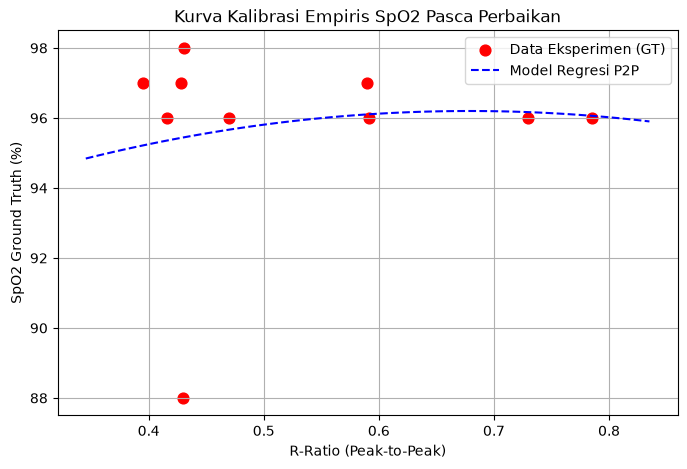

In [2]:

# --- 1. Fungsi Preprocessing & Ekstraksi Fitur ---
def baseline_correction(time, x, fs):
    min_distance = int(0.5 * fs) 
    peaks, _ = find_peaks(-x, distance=min_distance, prominence=0.1)

    if len(peaks) < 2:
        raise ValueError('lembah terlalu sedikit untuk interpolasi')
    
    t_val = time[peaks]
    s_val = x[peaks]

    cs = CubicSpline(t_val, s_val, bc_type='natural')
    baseline_dc = cs(time)
    x_corrected = x - baseline_dc

    return x_corrected, baseline_dc, t_val, s_val

def bpf(x, low_cut=0.5, high_cut=10, fs=125, order=4):
    nyq = 0.5 * fs
    low = low_cut / nyq
    high = high_cut / nyq

    b, a = butter(order, [low, high], btype='bandpass', analog=False)
    clean_ppg = filtfilt(b, a, x)
    return clean_ppg

def calculate_ac_peak_to_peak(ac_signal, fs, prominence_val=10):
    """
    Mengekstrak amplitudo AC dengan mencari selisih puncak dan lembah
    pada setiap detak jantung (Beat-by-Beat).
    """
    min_distance = int(0.5 * fs) # minimal 0.5 detik antar detak (~120 BPM)
    
    # Cari puncak (sistolik) dan lembah (diastolik) pada sinyal AC bersih
    peaks, _ = find_peaks(ac_signal, distance=min_distance, prominence=prominence_val)
    troughs, _ = find_peaks(-ac_signal, distance=min_distance, prominence=prominence_val)
    
    num_beats = min(len(peaks), len(troughs))
    if num_beats == 0:
        return None
        
    # Hitung selisih puncak-ke-lembah untuk setiap detak yang valid
    p2p_values = []
    for i in range(num_beats):
        amp_ac = ac_signal[peaks[i]] - ac_signal[troughs[i]]
        p2p_values.append(amp_ac)
        
    return np.mean(p2p_values)

# --- 2. Konfigurasi Parameter ---
fs_original = 400
fs_target = 125
PROMINENCE_CONFIG = 10  # Sesuaikan dengan skala amplitudo AC data STM32 Anda

list_r_ratio = []
list_spo2_gt = []

# --- 3. Looping Proses 10 File CSV ---
for index in range(1, 11):
    filename = f"Data{index}.csv"
    
    if not os.path.exists(filename):
        print(f"[WARN] File {filename} tidak ditemukan, skip.")
        continue
        
    df = pd.read_csv(filename)
    time_raw = df['Time (s)'].values
    ppg_ir_raw = df['PPG_IR'].values
    ppg_red_raw = df['PPG_Red'].values
    spo2_gt = df['SpO2_Ground_Truth'].iloc[0]
    
    # A. Invert Sinyal PPG Asli
    ppg_ir_inv = -ppg_ir_raw
    ppg_red_inv = -ppg_red_raw
    
    # B. Downsample ke 125 Hz
    num_samples = int(len(df) * fs_target / fs_original)
    ir_resampled = resample(ppg_ir_inv, num_samples)
    red_resampled = resample(ppg_red_inv, num_samples)
    time_resampled = np.linspace(time_raw[0], time_raw[-1], num_samples)
    
    try:
        # C. Baseline Correction (Spline untuk DC)
        ir_corrected, dc_ir_spline, _, _ = baseline_correction(time_resampled, ir_resampled, fs_target)
        red_corrected, dc_red_spline, _, _ = baseline_correction(time_resampled, red_resampled, fs_target)
        
        # D. Bandpass Filter (0.5 Hz - 10 Hz untuk AC)
        ir_clean = bpf(ir_corrected, low_cut=0.5, high_cut=10, fs=fs_target)
        red_clean = bpf(red_corrected, low_cut=0.5, high_cut=10, fs=fs_target)
        
        # E. Ekstraksi Fitur Metode Perbaikan: Peak-to-Peak (AC) & Mean Absolute (DC)
        ac_ir_p2p = calculate_ac_peak_to_peak(ir_clean, fs_target, PROMINENCE_CONFIG)
        ac_red_p2p = calculate_ac_peak_to_peak(red_clean, fs_target, PROMINENCE_CONFIG)
        
        if ac_ir_p2p is None or ac_red_p2p is None:
            print(f"[WARN] {filename} diskip karena tidak mendeteksi detak yang valid.")
            continue
            
        mean_dc_ir = np.mean(np.abs(dc_ir_spline))
        mean_dc_red = np.mean(np.abs(dc_red_spline))
        
        # F. Hitung R-ratio
        r_ratio = (ac_red_p2p / mean_dc_red) / (ac_ir_p2p / mean_dc_ir)
        
        list_r_ratio.append(r_ratio)
        list_spo2_gt.append(spo2_gt)
        
        print(f"[INFO] {filename} berhasil: R = {r_ratio:.4f} | GT SpO2 = {spo2_gt}%")
        
    except Exception as e:
        print(f"[ERROR] Gagal memproses {filename}: {e}")

# --- 4. Hitung Koefisien Kuadratik Baru ---
R_array = np.array(list_r_ratio)
SpO2_array = np.array(list_spo2_gt)

if len(R_array) >= 3:
    coefficients = np.polyfit(R_array, SpO2_array, 2)
    A, B, C = coefficients[0], coefficients[1], coefficients[2]
    
    print("\n" + "="*50)
    print("   HASIL PERBAIKAN KALIBRASI KUADRATIK (P2P)   ")
    print("="*50)
    print(f"Nilai A (koefisien R^2) : {A:.4f}")
    print(f"Nilai B (koefisien R)   : {B:.4f}")
    print(f"Nilai C (konstanta)     : {C:.4f}")
    print("-"*50)
    print(f"Rumus Implementasi Akhir Anda:")
    print(f"spo2 = {A:.4f} * (r_ratio**2) + ({B:.4f}) * r_ratio + {C:.4f}")
    print("="*50)
    
    # Plot Grafik Diagnostik Baru
    plt.figure(figsize=(8, 5))
    plt.scatter(R_array, SpO2_array, color='red', s=60, label='Data Eksperimen (GT)')
    r_smooth = np.linspace(min(R_array) - 0.05, max(R_array) + 0.05, 100)
    spo2_smooth = A * (r_smooth**2) + B * r_smooth + C
    plt.plot(r_smooth, spo2_smooth, color='blue', linestyle='--', label='Model Regresi P2P')
    plt.xlabel('R-Ratio (Peak-to-Peak)')
    plt.ylabel('SpO2 Ground Truth (%)')
    plt.title('Kurva Kalibrasi Empiris SpO2 Pasca Perbaikan')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("[ERROR] Data tidak cukup untuk membuat regresi kuadratik.")